In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [3]:
Root = Path.cwd()

# P1 Load ,clean and  Merge

In [4]:
# Load Deliveries Data

root = Path("..")
del_df = pd.read_csv(Root/"Data/row/deliveries.csv")

print("shape:",del_df.shape)
print()
display(del_df.head())
print("")
print(del_df.info())

shape: (13, 6)



,record_id,month,route_id,hub,promised_days,actual_days
0,1,Jan,R1,Mumbai,2,2
1,2,Jan,R2,Chennai,3,4
2,3,Jan,R3,Delhi,5,8
3,4,Jan,R4,Mumbai,6,10
4,5,Feb,R1,Chennai,2,5



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   record_id      13 non-null     int64 
 1   month          13 non-null     object
 2   route_id       13 non-null     object
 3   hub            13 non-null     object
 4   promised_days  13 non-null     int64 
 5   actual_days    13 non-null     int64 
dtypes: int64(3), object(3)
memory usage: 756.0+ bytes
None


In [5]:
# Load routes Data

rout_df = pd.read_csv("Data/row/routes.csv")

print("shape:",rout_df.shape)
print()
display(rout_df.head())
print("")
print(rout_df.info())

shape: (4, 3)



,route_id,route,service_type
0,R1,Metro Link,Express
1,R2,City Dash,Express
2,R3,Highway Freight,Standard
3,R4,Rural Feeder,Standard



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   route_id      4 non-null      object
 1   route         4 non-null      object
 2   service_type  4 non-null      object
dtypes: object(3)
memory usage: 228.0+ bytes
None


In [6]:
# remove the duoliate
before_dupi_shape = del_df.shape
del_df = del_df.drop_duplicates().copy()
after_dupi_shape = del_df.shape

print("Before del_df shape:",before_dupi_shape)
print("\nAfter del_df shape:",after_dupi_shape)

Before del_df shape: (13, 6)

After del_df shape: (12, 6)


In [7]:
# merge
merge_df = del_df.merge(
    rout_df,on="route_id",how="left",validate="many_to_one")
print("shape of merge:",merge_df.shape)
print()
display(merge_df)

shape of merge: (12, 8)



,record_id,month,route_id,hub,promised_days,actual_days,route,service_type
0,1,Jan,R1,Mumbai,2,2,Metro Link,Express
1,2,Jan,R2,Chennai,3,4,City Dash,Express
2,3,Jan,R3,Delhi,5,8,Highway Freight,Standard
3,4,Jan,R4,Mumbai,6,10,Rural Feeder,Standard
4,5,Feb,R1,Chennai,2,5,Metro Link,Express
5,6,Feb,R2,Delhi,3,3,City Dash,Express
6,7,Feb,R3,Delhi,5,10,Highway Freight,Standard
7,8,Feb,R4,Chennai,6,7,Rural Feeder,Standard
8,9,Mar,R1,Delhi,2,8,Metro Link,Express
9,10,Mar,R2,Mumbai,3,5,City Dash,Express


# P2 — Derived Field & Service-Type Analysis

In [8]:
merge_df["delay_days"] = merge_df["actual_days"] - merge_df["promised_days"].clip(lower=0)


display(merge_df)

,record_id,month,route_id,hub,promised_days,actual_days,route,service_type,delay_days
0,1,Jan,R1,Mumbai,2,2,Metro Link,Express,0
1,2,Jan,R2,Chennai,3,4,City Dash,Express,1
2,3,Jan,R3,Delhi,5,8,Highway Freight,Standard,3
3,4,Jan,R4,Mumbai,6,10,Rural Feeder,Standard,4
4,5,Feb,R1,Chennai,2,5,Metro Link,Express,3
5,6,Feb,R2,Delhi,3,3,City Dash,Express,0
6,7,Feb,R3,Delhi,5,10,Highway Freight,Standard,5
7,8,Feb,R4,Chennai,6,7,Rural Feeder,Standard,1
8,9,Mar,R1,Delhi,2,8,Metro Link,Express,6
9,10,Mar,R2,Mumbai,3,5,City Dash,Express,2


In [9]:
serivce_type_summary = merge_df.groupby(
    "service_type",as_index=False)["delay_days"].sum().sort_values("delay_days",ascending=False)

serivce_type_summary
total_delay=merge_df["delay_days"].sum()
serivce_type_summary["delay_days_%"] = serivce_type_summary["delay_days"] * 100 / total_delay

In [10]:
serivce_type_summary

,service_type,delay_days,delay_days_%
1,Standard,22,64.705882
0,Express,12,35.294118


In [11]:
route_summary = merge_df.groupby(
    "route",as_index=False)["delay_days"].sum()

route_summary["delay_days_%"] = route_summary["delay_days"] * 100 / total_delay
display(route_summary)

,route,delay_days,delay_days_%
0,City Dash,3,8.823529
1,Highway Freight,8,23.529412
2,Metro Link,9,26.470588
3,Rural Feeder,14,41.176471


# P3 — Chart & Exports

In [12]:
merge_df["month"] = pd.Categorical(merge_df["month"],categories=["Jan","Feb","Mar"],ordered=False)
month_summary  = merge_df.groupby("month",as_index=False)["delay_days"].sum()

C:\Users\MAYUR MAKVANA\AppData\Local\Temp\ipykernel_452\279980730.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  month_summary  = merge_df.groupby("month",as_index=False)["delay_days"].sum()


In [13]:
month_summary

,month,delay_days
0,Jan,8
1,Feb,9
2,Mar,17


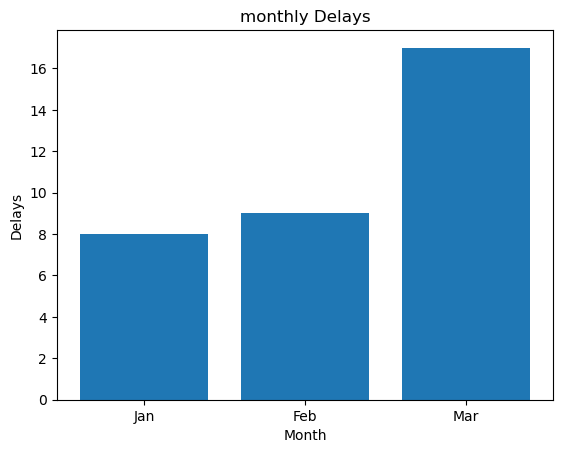

In [14]:
plt.bar(month_summary["month"],month_summary["delay_days"])
plt.xlabel("Month")
plt.ylabel("Delays")
plt.title("monthly Delays")
plt.savefig("output/python_chart")
plt.show()

In [15]:
# save all files
# save clean file
merge_df.to_csv("output/clean_data.csv",index=False)
# save group by summary
serivce_type_summary.to_csv("output/serivce_type_summary.csv")
route_summary.to_csv("output/route_summary.csv")